# poly2mask.ipynb

In [1]:
import numpy as np
import shapely.wkt as wkt
from matplotlib.figure import Figure
import matplotlib.pyplot as plt
import sqlite3
import pandas as pd
from icecream import ic
import cv2
from skimage.measure import perimeter
import pyefd
import datetime

# Functions

In [1]:
import matplotlib.pyplot as plt
from matplotlib.figure import Figure
import datetime

def optional_plotting_example(show_plot=False, save_plot=False):
    """ 
    This is an example of how to enable optional plotting within a function.
    """
    data = np.random.random(5)
    timestamp = datetime.datetime.now().astimezone().replace(microsecond=0).isoformat()
    plot_title = f'optional plotting example {timestamp}'
    plot_path = f'optional_plotting_example_{timestamp}.png'
    
    # OPTIONAL PLOTTING
    if show_plot or save_plot:
        
        # MODIFY THIS CODE BLOCK TO CREATE A NICE FIGURE TO DISPLAY YOUR DATA
        
        # Create a figure without using plt.figure()
        # Avoids global registration problems
        fig = Figure()
        ax = fig.add_subplot()
        ax.plot(data)
        ax.set_title(plot_title)
        
        #################################################
        # START OF BOILER PLATE CODE FOR PLOTTING OPTIONS
        if save_plot:
            fig.savefig(plot_path)   
        if show_plot:
            display(fig) # Or plt.show()  
         # END OF BOILER PLATE CODE FOR PLOTTING OPTIONS
         ###############################################
                      
    return data

# Usage examples:

# plotting is disabled (default)
# optional_plotting_example() 

# plot is displayed but not saved
# optional_plotting_example(show_plot=True)

# plot is saved but not displayed 
# optional_plotting_example(save_plot=True) 

# plot is displayed and saved
# optional_plotting_example(show_plot=True, save_plot=True)          

In [88]:
import numpy as np
import cv2
from shapely.geometry import Polygon
from shapely import affinity

def polygon_to_mask2(
    poly_wkt: str, 
    size: int = 1080, 
    padding: int = 20, 
    show_plot: bool = False, 
    save_plot: bool = False,
    plot_title: str = 'plot_title',
    plot_path: str = 'plot_path.png'
    ) -> np.ndarray:
    """
    Rescale and translate a Shapely polygon to fit a centered box with strict padding.

    Uses the bounding box center rather than the centroid to ensure that 
    the 10-pixel padding is strictly respected on all four edges.

    Args:
        poly_wkt:   Shapely Polygon object to be transformed.
        size:       width and height of the output square mask in pixels.
        padding:    zero-padding on all four edges, in pixels
        show_plot:  option to show the plot 
        save_plot:  option to save the plot
        plot_title: plot title
        plot_path:  file path for saving the plot
        
    Note:    
        If plot_path contains a directory, the user is responsible for ensuring its existence.
        Use of 'os.makedirs('my_masks',exist_ok=True)' is suggested for this.

    Returns:
        A NumPy array of shape (size, size) representing the binary mask.
    """
    poly = wkt.loads(r['poly_wkt'])

    # 1. Calculate current bounding box dimensions
    minx, miny, maxx, maxy = poly.bounds
    width = maxx - minx
    height = maxy - miny
    
    if width == 0 or height == 0:
        return np.zeros((size, size), dtype=np.uint8)

    # 2. Calculate scale factor to fit the safe zone (size - 2 * padding)
    safe_limit = size - (2 * padding)
    scale_factor = safe_limit / max(width, height)

    # 3. Center based on the BOUNDING BOX center, not the centroid
    # This ensures the furthest points in any direction are equidistant from the edges
    bbox_center_x = (minx + maxx) / 2.0
    bbox_center_y = (miny + maxy) / 2.0
    
    # Move BBox center to (0,0)
    poly_centered = affinity.translate(poly, xoff=-bbox_center_x, yoff=-bbox_center_y)
    
    # Scale at the origin (0,0)
    poly_scaled = affinity.scale(
        poly_centered, xfact=scale_factor, yfact=scale_factor, origin=(0, 0)
    )

    # 4. Shift to the absolute center of the image coordinate system
    # For a 1080px image, the midpoint is 540.0
    img_midpoint = size / 2.0
    poly_final = affinity.translate(poly_scaled, xoff=img_midpoint, yoff=img_midpoint)

    # 5. Rasterize
    mask = np.zeros((size, size), dtype=np.uint8)
    # Use np.int32 for OpenCV fillPoly; coordinates are rounded to nearest pixel
    coords = np.array(poly_final.exterior.coords, dtype=np.int32)
    mask = cv2.fillPoly(mask, [coords], 1)
    
    # OPTIONAL PLOTTING
    if show_plot or save_plot:
        
        # MODIFY THIS CODE BLOCK TO CREATE A NICE FIGURE TO DISPLAY YOUR DATA
        
        # Create a figure without using plt.figure()
        # Avoids global registration problems
        fig = Figure()
        ax = fig.add_subplot()
        ax.imshow(mask, cmap='gray')
        ax.set_title(plot_title)
        
        #################################################
        # START OF BOILER PLATE CODE FOR PLOTTING OPTIONS
        if save_plot:
            fig.savefig(plot_path)   
        if show_plot:
            display(fig) # Or plt.show()  
         # END OF BOILER PLATE CODE FOR PLOTTING OPTIONS
         ###############################################
    
    return mask


In [50]:
# import cv2 
# import numpy
# from pyefd import elliptic_fourier_descriptors

def get_mask_contour(
    mask: np.array,
    show_plot: bool = False, 
    save_plot: bool = False,
    plot_title: str = 'plot_title',
    plot_path: str = 'plot_path.png'
    ) -> np.ndarray:

    # Find the contours of a binary image using OpenCV.
    contours, hierarchy = cv2.findContours(mask, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    if len(contours) >  1:
        print(f'### WARNING: {len(contours)} contours detected. Using the first one.');
    contour = contours[0].squeeze()
    
    # OPTIONAL PLOTTING
    if show_plot or save_plot:
        xs, ys = contour.T

        # MODIFY THIS CODE BLOCK TO CREATE A NICE FIGURE TO DISPLAY YOUR DATA
        
        # Create a figure without using plt.figure()
        # Avoids global registration problems
        fig = Figure()
        ax = fig.add_subplot()
        
        ax.plot(xs, ys, linewidth=3)
        ax.invert_yaxis()  # Invert y-axis to match image coordinates
        ax.set_aspect('equal')                
        ax.set_title(plot_title)
        
        #################################################
        # START OF BOILER PLATE CODE FOR PLOTTING OPTIONS
        if save_plot:
            fig.savefig(plot_path)   
        if show_plot:
            display(fig) # Or plt.show()  
        # END OF BOILER PLATE CODE FOR PLOTTING OPTIONS
        ###############################################
    
    return contour


# Main

In [ ]:
efd_order = 55

In [ ]:
# Read WKT from SQLite and convert to Shapely geometry
df = pd.read_sql(
    "SELECT detection_id, poly_wkt FROM detections WHERE detection_id=17;", 
    sqlite3.connect('sam3_detections.sqlite3')
)
wkt_str = df.at[0, 'poly_wkt']
poly = wkt.loads(wkt_str)
x, y = poly.exterior.xy

# Plot
fig, ax = plt.subplots()
ax.plot(x, y, linewidth=1)
ax.invert_yaxis()  # Invert y-axis to match image coordinates
ax.set_aspect('equal')
ax.set_title('polygon coordinates');

In [ ]:
coords = np.array(poly.exterior.coords, dtype=np.int32)
coords = coords - np.min(coords, axis=0)
ic(coords[:10])
ic(np.max(coords, axis=0))

# coords = coords + 10
ic(coords[:10])
ic(np.max(coords, axis=0))
xs, ys = coords.T
ic(min(xs), max(xs), min(ys), max(ys))

fig, ax = plt.subplots()
ax.plot(xs, ys, linewidth=1)
ax.set_aspect('equal')
ax.invert_yaxis()  # Invert y-axis to match image coordinates
ax.set_title('coordinates translated so that min(x)=0 and min(y)=0');

In [ ]:
mask = cv2.fillPoly(np.zeros((max(ys), max(xs)), dtype=np.uint8), [coords], 1)
mask = np.pad(mask, pad_width=10, mode='constant', constant_values=0)

fig, ax = plt.subplots()
ax.imshow(mask, cmap='gray')
ax.set_title('coordinates converted to mask');

In [ ]:
# Calculating ones in edges
arr = mask
top_ones = np.sum(arr[0, :])
bottom_ones = np.sum(arr[-1, :])
left_ones = np.sum(arr[:, 0])
right_ones = np.sum(arr[:, -1])
ic(top_ones, bottom_ones, left_ones, right_ones)

In [ ]:
height, width = mask.shape
ic(mask.shape)
ic(perimeter(mask, neighborhood=4) )

target_dimension = 1080
if height > width:
    ratio = target_dimension / float(height)
else:
    ratio = target_dimension / float(width) 
new_height = int(ratio * height)
new_width = int(ratio * width)
resized_mask = cv2.resize(mask, (new_width, new_height), interpolation=cv2.INTER_AREA)
ic(resized_mask.shape)
ic(np.max(resized_mask))
ic(perimeter(resized_mask, neighborhood=4) )

fig, ax = plt.subplots()
ax.imshow(resized_mask, cmap='gray')
ax.set_title('rescaled so that max dimension is 1080 pixels');

In [ ]:
# calculate EFD coefficients
coeffs = pyefd.elliptic_fourier_descriptors(contour, order=efd_order, normalize=False)
ic(coeffs.shape);

In [ ]:
# Plot
fig, ax = plt.subplots()
ax.plot(xs, ys, linewidth=1)
ax.invert_yaxis()  # Invert y-axis to match image coordinates
ax.set_aspect('equal')
ax.set_title('original contour');

# Reconstruct contour using EFD coefficients
reconstructed_contour = pyefd.reconstruct_contour(coeffs)
ic(reconstructed_contour)


# Plot
r_xs, r_ys = reconstructed_contour.T

fig, ax = plt.subplots()
ax.plot(r_xs, r_ys, linewidth=1)
ax.set_aspect('equal')
ax.invert_yaxis()  # Invert y-axis to match image coordinates
ax.set_title('reconstructed_contour');



In [ ]:
from shapely.affinity import translate
from shapely.geometry import Polygon

def center_polygon(p: Polygon) -> Polygon:
    "Returns a shaply Polygon with centroid translated to (0, 0)"
    centroid = p.centroid
    return translate(p, xoff=-centroid.x, yoff=-centroid.y)

def calc_iou(p1: Polygon, p2: Polygon) -> float:
    "Returns IoU for 2 shapely Polygons"
    try:
        intersection = p1.intersection(p2)
    except:
        return -1
    union = p1.area + p2.area - intersection.area 
    return intersection.area / union


In [ ]:
# Convert 'contour' to shapely polygon
p1 = Polygon(contour)
p2 = Polygon(reconstructed_contour)

cp1 = center_polygon(p1)
ic(cp1.centroid)

cp2 = center_polygon(p2)
ic(cp2.centroid)

iou = calc_iou(cp1, cp2)
ic(iou);

In [ ]:
# plot original contour and reconstructed contour in the same axes
fig, ax = plt.subplots()
fig.set

xs, ys = cp1.exterior.coords.xy
plt.plot(xs, ys, label='original contour', linewidth=1)
xs, ys = cp2.exterior.coords.xy
plt.plot(xs, ys, label='reconstructed contour', linewidth=1)
ax.set_aspect('equal')
ax.invert_yaxis()  # Invert y-axis to match image coordinates
ax.legend(loc='best')
ax.set_title(f'EFD order:{efd_order} IoU:{iou:.3f}');


In [ ]:
def check_padding(binary_image):
    """ Check for padding on edges of a binary image."""
    arr = mask
    top_ones = np.sum(arr[0, :])
    bottom_ones = np.sum(arr[-1, :])
    left_ones = np.sum(arr[:, 0])
    right_ones = np.sum(arr[:, -1])
    ic(top_ones, bottom_ones, left_ones, right_ones)

In [ ]:
def calc_best_efd_order(poly: Polygon) -> dict:
    """ 
    Calculates the 'best' efd order parameter for a detected object.
    efd_order is increased until the IoU for ploy and reconstructed_poly decreases.
    
    Input:
      poly: shapely polygon for a detected object
      
    Returns:
      a dict containing efd_order and iou
    """ 
    # transform the polygon into an 1080x1080 image of a binary mask 
    mask = polygon_to_mask2(poly)
    check_padding(mask)
    
    # contour the mask using opencv
    # Find the contours of a binary image using OpenCV.
    contours, hierarchy = cv2.findContours(im, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    assert len(contours) == 1 # ONLY 1 CONTOUR IS EXPECTED
    contour = contours[0].squeeze()
    
    results = []
    for efd_order in range(30, 61):
        # calculate EFD coefficients
        coeffs = pyefd.elliptic_fourier_descriptors(contour, order=efd_order, normalize=False)
        reconstructed_contour = pyefd.reconstruct_contour(coeffs)

        # Convert 'contour' to shapely polygon
        p1 = Polygon(contour)
        p2 = Polygon(reconstructed_contour)

        cp1 = center_polygon(p1)
        ic(cp1.centroid)

        cp2 = center_polygon(p2)
        ic(cp2.centroid)

        iou = calc_iou(cp1, cp2)
        ic(iou);
        
        results.append({'efd_order':efd_order, 'iou': iou})        
        
    return results

# Usage example:

wkt_str = df.at[0, 'poly_wkt']
poly = wkt.loads(wkt_str)
results = calc_best_efd_order(poly)
df_results = pd.DataFrame(results)
df_results

In [ ]:
df_results.plot(x='efd_order', y='iou', ylim=(0.0, 1.0), linewidth=1);

# Main


i=0


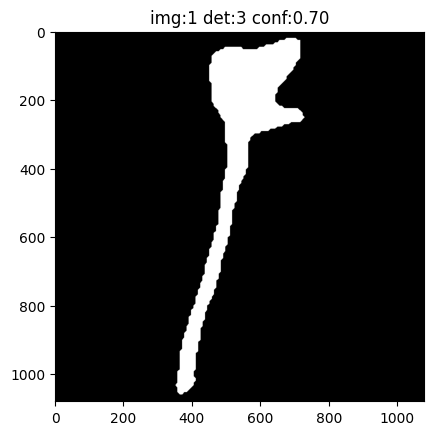

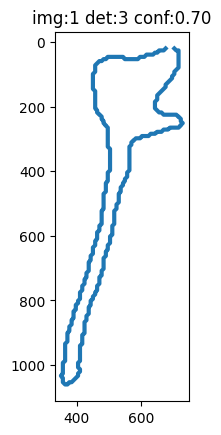

contour.size=498
efd_coeffs.size=200
efd_coeffs[0:2]=array([[ 114.63888165,  -61.72297805, -444.82761486,    4.74156264],
       [  -3.15856343,  -36.97479377,   36.07867879,  -29.25035943]])


In [89]:
import pandas as pd
import sqlite3
import os
import shapely.wkt as wkt
from icecream import ic
import pyefd


# Get data
df = pd.read_sql(
    "SELECT * FROM detections WHERE detection_id = 3;", 
    sqlite3.connect('sam3_detections.sqlite3')
)
df.sort_values(by='confidence', ascending=False, inplace=True, ignore_index=True)

# Ensure there is a directory in which to store mask and contour plots
os.makedirs('masks',exist_ok=True)
os.makedirs('contours',exist_ok=True)

for i, r in df.iterrows():
    print()
    print(f'{i=}')
    
    # Create masks using data from the poly_wkt field
    mask = polygon_to_mask2(
        poly_wkt = r['poly_wkt'], 
        show_plot=True, 
        save_plot=False, 
        plot_title=f'img:{r['image_id']} det:{r['detection_id']} conf:{r['confidence']:.2f}', 
        plot_path=f'masks/{i}.png'
        ) 
    
    # Create contours from masks  
    contour = get_mask_contour(
        mask, 
        show_plot=True,
        plot_title=f'img:{r['image_id']} det:{r['detection_id']} conf:{r['confidence']:.2f}',       
        save_plot=False,
        plot_path=f'contours/{i}.png'
        )
    print(f'{contour.size=}')
    
    # Create elliptic Fourier descriptors from contours
    efd_coeffs = pyefd.elliptic_fourier_descriptors(contour, order=50, normalize=False)
    print(f'{efd_coeffs.size=}')
    print(f'{efd_coeffs[0:2]=}')


In [ ]:
c = contour
ic(c.shape)
ic(c)

ic| c.shape: (241, 2)


(241, 2)

In [61]:
contour[-5:]

array([[718,  16],
       [712,  16],
       [709,  13],
       [708,  13],
       [705,  10]], dtype=int32)

In [65]:
polygon = contour
# Assume polygon is (N, 2) array
diff = np.diff(polygon, axis=0)
distances = np.sqrt(np.sum(diff**2, axis=1))
# Gap exists where distances are unusually large
gap_index = np.argmax(distances) 
gap_index


np.int64(186)

In [66]:
polygon[180:190]

array([[543, 442],
       [543, 435],
       [550, 428],
       [550, 421],
       [556, 415],
       [556, 401],
       [563, 394],
       [563, 320],
       [570, 313],
       [570, 307]], dtype=int32)

In [68]:
np.zip(polygon, distances)

AttributeError: module 'numpy' has no attribute 'zip'

In [85]:
c

array([[ 678,   10],
       [ 675,   13],
       [ 674,   13],
       [ 671,   16],
       [ 658,   16],
       [ 651,   23],
       [ 644,   23],
       [ 637,   30],
       [ 617,   30],
       [ 610,   37],
       [ 597,   37],
       [ 594,   40],
       [ 593,   40],
       [ 590,   43],
       [ 550,   43],
       [ 547,   40],
       [ 546,   40],
       [ 543,   37],
       [ 496,   37],
       [ 493,   40],
       [ 492,   40],
       [ 489,   43],
       [ 482,   43],
       [ 475,   50],
       [ 469,   50],
       [ 455,   64],
       [ 455,   84],
       [ 448,   91],
       [ 448,  138],
       [ 455,  145],
       [ 455,  199],
       [ 458,  202],
       [ 459,  202],
       [ 462,  205],
       [ 462,  212],
       [ 468,  218],
       [ 468,  219],
       [ 475,  226],
       [ 475,  232],
       [ 482,  239],
       [ 482,  246],
       [ 488,  252],
       [ 489,  252],
       [ 496,  259],
       [ 496,  320],
       [ 499,  323],
       [ 499,  324],
       [ 502,

In [83]:
is_closed = np.allclose(c[0], c[-1])
if not is_closed:
    print(f"Gap between {c[-1]} and {c[0]}")


Gap between [705  10] and [678  10]


In [80]:
polygon[-2:]

array([[708,  13],
       [705,  10]], dtype=int32)

In [87]:
import numpy as np

def close_polygon(polygon_points):
  """
  Ensures a polygon is closed by checking if the first and last points are the same,
  and if not, appends the first point to the end.

  Args:
    polygon_points: A NumPy array of shape (N, 2) or (N, 3) representing the vertices.

  Returns:
    A closed NumPy array of vertices.
  """
  # Check if the first and last rows (points) are the same
  if not np.array_equal(polygon_points[0], polygon_points[-1]):
    # If not closed, append the first point to the end
    closed_points = np.concatenate((polygon_points, [polygon_points[0]]), axis=0)
    print("Polygon was not closed. First point appended.")
    return closed_points
  else:
    print("Polygon is already closed.")
    return polygon_points

# Example Usage:
# An open polygon (4 points, but only 3 distinct vertices)
open_poly = np.array([[0, 0], [1, 0], [1, 1], [0, 1]])

# Close the polygon
closed_poly = close_polygon(open_poly)
print(closed_poly)

# An already closed polygon
closed_poly_input = np.array([[0, 0], [1, 0], [1, 1], [0, 1], [0, 0]])
already_closed = close_polygon(closed_poly_input)
print(already_closed)

close_polygon(c)


Polygon was not closed. First point appended.
[[0 0]
 [1 0]
 [1 1]
 [0 1]
 [0 0]]
Polygon is already closed.
[[0 0]
 [1 0]
 [1 1]
 [0 1]
 [0 0]]
Polygon was not closed. First point appended.


array([[ 678,   10],
       [ 675,   13],
       [ 674,   13],
       [ 671,   16],
       [ 658,   16],
       [ 651,   23],
       [ 644,   23],
       [ 637,   30],
       [ 617,   30],
       [ 610,   37],
       [ 597,   37],
       [ 594,   40],
       [ 593,   40],
       [ 590,   43],
       [ 550,   43],
       [ 547,   40],
       [ 546,   40],
       [ 543,   37],
       [ 496,   37],
       [ 493,   40],
       [ 492,   40],
       [ 489,   43],
       [ 482,   43],
       [ 475,   50],
       [ 469,   50],
       [ 455,   64],
       [ 455,   84],
       [ 448,   91],
       [ 448,  138],
       [ 455,  145],
       [ 455,  199],
       [ 458,  202],
       [ 459,  202],
       [ 462,  205],
       [ 462,  212],
       [ 468,  218],
       [ 468,  219],
       [ 475,  226],
       [ 475,  232],
       [ 482,  239],
       [ 482,  246],
       [ 488,  252],
       [ 489,  252],
       [ 496,  259],
       [ 496,  320],
       [ 499,  323],
       [ 499,  324],
       [ 502,

In [173]:
a = np.arange(25).reshape(5,5)
a[2] = np.zeros(5)
a[:,0] = np.zeros(5)
# a[:,-1] = np.zeros_like(a[:,-1])
a[:,-1] = 0




sum_first_row = np.sum(a[0, :])
print(f'{sum_first_row=}')

sum_last_row = np.sum(a[-1, :])
print(f'{sum_last_row=}')

sum_first_column = np.sum(a[:, 0])
print(f'{sum_first_column=}')

sum_last_column = np.sum(a[:, -1])
print(f'{sum_last_column=}')

all_zero_rows = np.where(~a.any(axis=1))[0]
print(f'{all_zero_rows=}')

all_zero_columns = np.where(~a.any(axis=0))[0]
print(f'{all_zero_columns=}')

sum_first_row=np.int64(6)
sum_last_row=np.int64(66)
sum_first_column=np.int64(0)
sum_last_column=np.int64(0)
all_zero_rows=array([2])
all_zero_columns=array([0, 4])


In [174]:
all_zero_rows.size

1